# Lecture 21: Actions

**Source span.** Printed pages 125-130; physical PDF pages 139-144 in `Lectures on Symplectic Geometry.pdf`.

**Chapter goal.** This lecture builds the language needed for moment maps. By the end of the notebook you should be able to move between a global group action, its infinitesimal vector field, the symplectic condition, the Hamiltonian condition for a one-parameter subgroup, and the adjoint/coadjoint bookkeeping that will make the next lecture's moment map equivariant.

The chapter has five conceptual layers. A complete vector field gives a one-parameter group of diffeomorphisms, and uniqueness of integral curves is the reason the flow law `rho_t rho_s = rho_{t+s}` holds. Lie groups package smooth group operations; their smooth actions are homomorphisms into diffeomorphisms with a smooth evaluation map. A symplectic action is an action through symplectomorphisms. For `R` and `S^1`, being Hamiltonian means the generated vector field has a Hamiltonian function. For general Lie groups, the lecture prepares the adjoint and coadjoint representations, because moment maps must land in `g*` and transform by the coadjoint action.

This notebook does not reproduce the source proofs or exercises. Instead it gives a computational translation of every major ingredient: flows become matrix identities and orbit traces, symplectic preservation becomes `A.T J A = J`, Hamiltonian generation becomes a contraction identity, and the Hermitian-matrix homework becomes a small orbit/stabilizer/spectrum experiment.

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import sympy as sp
from IPython.display import Image, display


def locate_book_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "artifacts").exists():
            return candidate
    raise RuntimeError("Run this notebook from inside the LSG course tree.")


BOOK_ROOT = locate_book_root()
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "lecture-21"
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
for folder in (FIGURES, CHECKS):
    folder.mkdir(parents=True, exist_ok=True)


def rel(path: Path) -> str:
    return path.relative_to(BOOK_ROOT).as_posix()


def write_json(path: Path, payload: dict) -> None:
    path.write_text(json.dumps(payload, indent=2), encoding="utf-8")


def display_artifact(relative_path: str, *, width: int = 760) -> None:
    display(Image(filename=str(BOOK_ROOT / relative_path), width=width))


source_span = {
    "lecture": 21,
    "title": "Actions",
    "printed_pages": "125-130",
    "physical_pdf_pages": "139-144",
    "source_note": (
        "Inspected the local PDF text for Lecture 21: one-parameter groups, "
        "Lie groups, smooth actions, symplectic and Hamiltonian actions, "
        "adjoint/coadjoint representations, and the Hermitian matrices homework."
    ),
}
write_json(CHECKS / "source-span.json", source_span)
source_span

{'lecture': 21,
 'title': 'Actions',
 'printed_pages': '125-130',
 'physical_pdf_pages': '139-144',
 'source_note': 'Inspected the local PDF text for Lecture 21: one-parameter groups, Lie groups, smooth actions, symplectic and Hamiltonian actions, adjoint/coadjoint representations, and the Hermitian matrices homework.'}

## Translation Guide

`Flow` means the map that sends a starting point to the point reached after time `t` by a complete vector field. The proof that flows form an `R`-action is not a new algebraic axiom; it is the uniqueness theorem for ordinary differential equations in disguise.

`Lie group` means a manifold whose multiplication and inverse maps are smooth. In code, small matrix groups are the easiest reliable model: rotations for `S^1 = SO(2)`, unitary matrices for `U(n)`, and invertible matrices for `GL(V)`.

`Smooth action` means a homomorphism `G -> Diff(M)` with a smooth evaluation map. The orbit through a point is what the group can reach from that point; the stabilizer is what acts invisibly at that point. The orbit/stabilizer split is the geometric grammar behind the examples in the lecture and the Hermitian-matrix homework.

`Symplectic action` means every group element preserves the two-form. For a matrix action on `R^{2n}`, that is the matrix equation `A.T J A = J`. `Hamiltonian action` for `R` or `S^1` means the infinitesimal generator `X#` satisfies `dH = i_X omega` for some Hamiltonian `H`.

`Adjoint representation` differentiates conjugation at the identity: matrix groups make this `Ad_g(Y) = gYg^{-1}`. The `coadjoint representation` is the dual action on `g*`; it is defined with `g^{-1}` in the pairing so that it is a left representation. This is the precise bookkeeping the next lecture will need for moment-map equivariance.

## Library Routing

Matplotlib is used for the orbit, flow, Hamiltonian, and Hermitian-orbit diagrams because the key geometry is visible in two-dimensional projections with labels and invariant overlays. NetworkX is used for the proof-route diagram because the lecture is definition-heavy and the dependencies are clearer as a directed graph. SymPy is used for the adjoint bracket check because the matrix identity is exact and should not depend on floating-point tolerance. NumPy supplies the small symplectic, unitary, and spectrum checks.

In [2]:
storyboard = {
    "chapter_goal": "Turn Lie-group actions into inspectable flows, orbits, generators, symplectic checks, Hamiltonian checks, and adjoint/coadjoint bookkeeping.",
    "source_span_read": source_span,
    "library_routing": [
        {
            "concept": "one-parameter groups of diffeomorphisms",
            "representation": "flow traces plus group-law endpoint check",
            "library": "Matplotlib + NumPy",
            "why": "the flow law and orbit geometry are visible as reachable points and exact matrix products",
            "fallback": "static table of rotation matrices",
        },
        {
            "concept": "smooth actions, orbits, stabilizers",
            "representation": "orbit/stabilizer panel for translations, rotations, and sphere parallels",
            "library": "Matplotlib",
            "why": "orbits are geometric subsets; stabilizers are easiest to compare beside the picture",
            "fallback": "text ledger",
        },
        {
            "concept": "symplectic and Hamiltonian actions",
            "representation": "vector-field and contraction check for translation and circle rotation",
            "library": "Matplotlib + NumPy",
            "why": "the two-form preservation and Hamiltonian identity become numerical residuals attached to the picture",
            "fallback": "matrix residual table",
        },
        {
            "concept": "adjoint and coadjoint representations",
            "representation": "proof dependency graph plus exact sl2 bracket check",
            "library": "NetworkX + SymPy",
            "why": "the representation law is a dependency chain and the derivative of conjugation is exact algebra",
            "fallback": "commutative diagram",
        },
        {
            "concept": "Hermitian matrix orbits",
            "representation": "Bloch-sphere model for 2x2 traceless Hermitian matrices",
            "library": "Matplotlib 3D + NumPy",
            "why": "unitary conjugation fixes spectrum, so the orbit is visible as a sphere of equal eigenvalues",
            "fallback": "eigenvalue table",
        },
    ],
    "visual_sequence": [
        {
            "concept": "Flow law from uniqueness of integral curves",
            "artifact": rel(FIGURES / "flow-law-one-parameter-action.png"),
            "inspection_target": "compare direct time t+s motion with composed t then s motion",
            "validation": "rotation matrix product residual is zero to numerical tolerance",
        },
        {
            "concept": "Orbits and stabilizers of smooth actions",
            "artifact": rel(FIGURES / "orbit-stabilizer-action-models.png"),
            "inspection_target": "see translation lines, rotation circles, and fixed-axis stabilizer behavior",
            "validation": "sample orbit dimensions match the stabilizer ledger",
        },
        {
            "concept": "Symplectic versus Hamiltonian one-parameter actions",
            "artifact": rel(FIGURES / "symplectic-hamiltonian-action-checks.png"),
            "inspection_target": "read which vector field preserves omega and which Hamiltonian generates it",
            "validation": "A.T J A = J and dH = i_X omega residuals vanish",
        },
        {
            "concept": "Adjoint/coadjoint representation bookkeeping",
            "artifact": rel(FIGURES / "adjoint-coadjoint-proof-route.png"),
            "inspection_target": "trace why conjugation, differentiation, and dual pairing feed moment-map equivariance",
            "validation": "sl2 derivative of Ad_exp(tX)Y equals [X,Y]",
        },
        {
            "concept": "Hermitian-matrix orbit homework",
            "artifact": rel(FIGURES / "hermitian-unitary-orbit-spectrum.png"),
            "inspection_target": "see fixed spectrum as the orbit surface and stabilizer as commuting directions",
            "validation": "unitary conjugation preserves eigenvalues; commutator kernel matches centralizer",
        },
    ],
    "computational_checks": [
        "rotation flow group law",
        "symplectic matrix residual",
        "Hamiltonian contraction identities for translation and rotation",
        "adjoint bracket derivative",
        "coadjoint pairing convention",
        "Hermitian orbit eigenvalue and centralizer checks",
    ],
}
write_json(CHECKS / "visual-storyboard.json", storyboard)
print("planned", len(storyboard["visual_sequence"]), "chapter-specific visuals")

planned 5 chapter-specific visuals


## One-Parameter Groups

The first source proof says: if `rho_t` is the flow of a complete vector field, then `rho_t(rho_s(q))` and `rho_{t+s}(q)` solve the same initial-value problem, so they are the same curve. The figure below makes that proof inspectable with a rotation flow. The blue point moves by time `s`, the orange point moves by an additional time `t`, and the green point goes directly by time `t+s`. The visual claim is not that rotations are the only flows; it is that a familiar complete vector field makes the group law concrete.

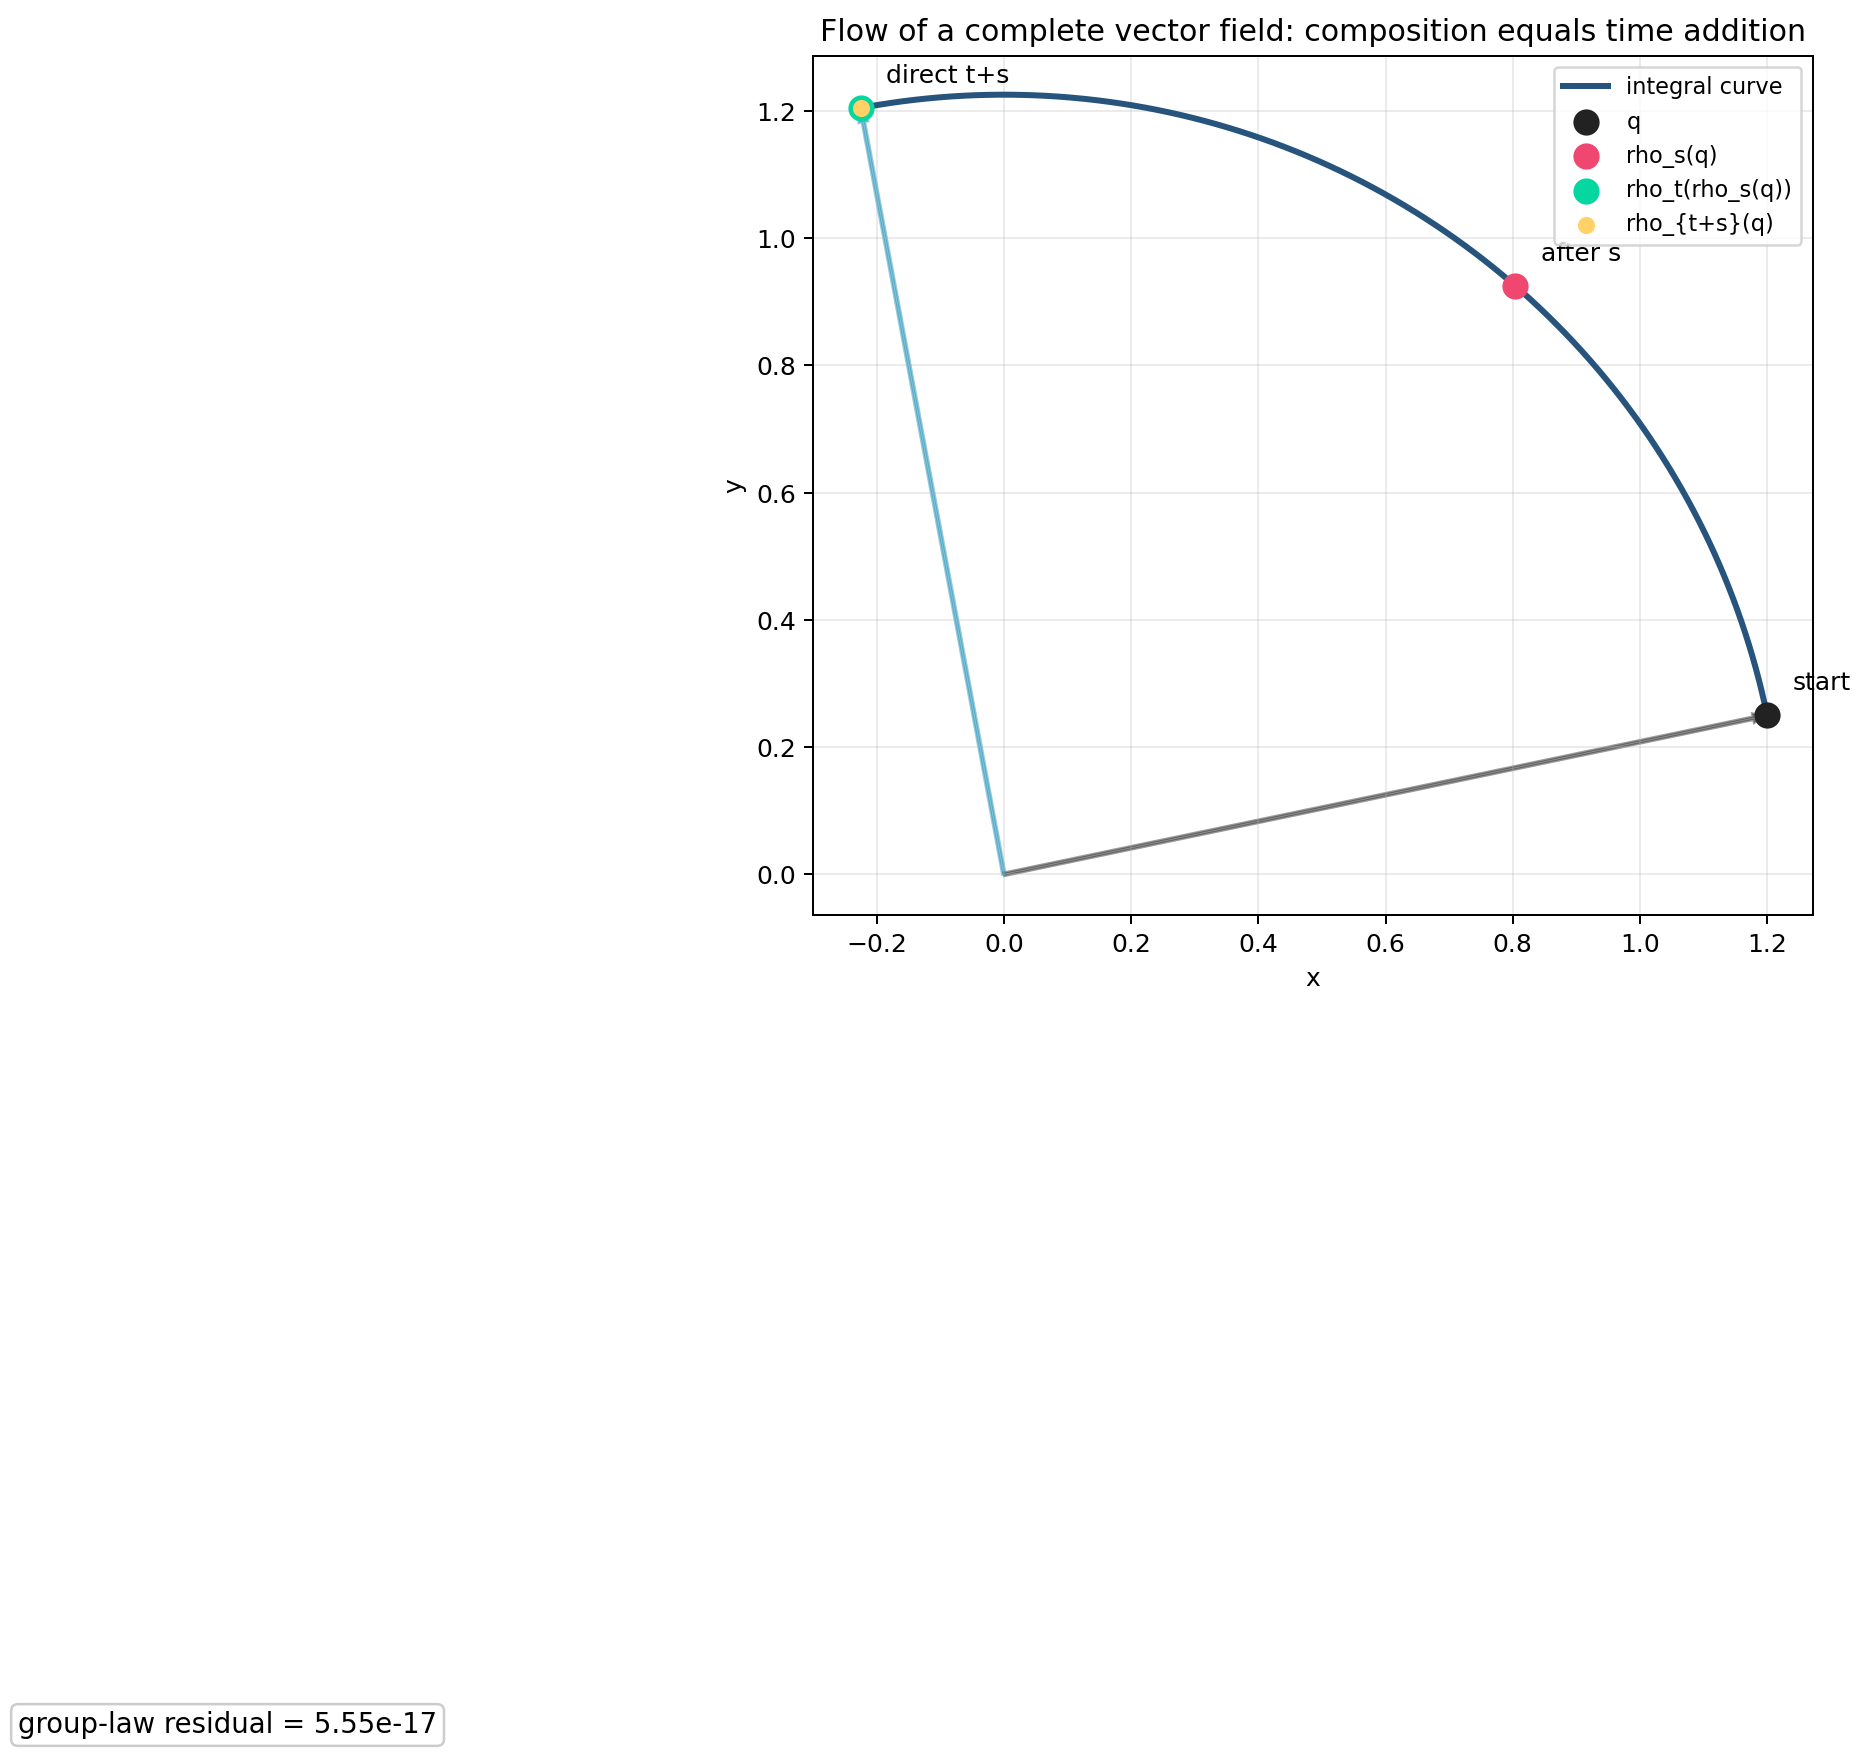

In [3]:
def rotation(theta: float) -> np.ndarray:
    c, s = math.cos(theta), math.sin(theta)
    return np.array([[c, -s], [s, c]])


t, s = 0.9, 0.65
q = np.array([1.2, 0.25])
after_s = rotation(s) @ q
after_t_then_s = rotation(t) @ after_s
after_direct = rotation(t + s) @ q
flow_residual = float(np.linalg.norm(after_t_then_s - after_direct))

theta = np.linspace(0, t + s, 200)
orbit = np.array([rotation(a) @ q for a in theta])

fig, ax = plt.subplots(figsize=(7.6, 6.2))
ax.plot(orbit[:, 0], orbit[:, 1], color="#26547c", lw=2.4, label="integral curve")
ax.scatter(*q, s=90, color="#222222", zorder=3, label="q")
ax.scatter(*after_s, s=90, color="#ef476f", zorder=3, label="rho_s(q)")
ax.scatter(*after_t_then_s, s=90, color="#06d6a0", zorder=4, label="rho_t(rho_s(q))")
ax.scatter(*after_direct, s=34, color="#ffd166", zorder=5, label="rho_{t+s}(q)")
for point, label in [(q, "start"), (after_s, "after s"), (after_direct, "direct t+s")]:
    ax.annotate(label, point + np.array([0.04, 0.04]), fontsize=10)
ax.arrow(0, 0, q[0], q[1], width=0.005, color="#222222", alpha=0.45, length_includes_head=True)
ax.arrow(0, 0, after_direct[0], after_direct[1], width=0.005, color="#118ab2", alpha=0.45, length_includes_head=True)
ax.text(-1.55, -1.35, f"group-law residual = {flow_residual:.2e}", fontsize=11, bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="#cccccc"))
ax.set_title("Flow of a complete vector field: composition equals time addition")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper right", fontsize=9)
flow_path = FIGURES / "flow-law-one-parameter-action.png"
fig.savefig(flow_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert flow_residual < 1e-12
display_artifact(rel(flow_path))

## Orbits, Stabilizers, And Smooth Actions

An action is a systematic way for group elements to move points. The lecture's examples are deliberately simple: translation by the flow of a complete vector field, rotation of the plane or sphere by `S^1`, and matrix-group actions by conjugation. The orbit is the reachable set; the stabilizer is the subgroup that leaves a point fixed. Those two objects are not decorative language: they determine the local shape of orbit spaces and foreshadow why quotient spaces can be badly behaved unless hypotheses are imposed.

The next panel compares three action models. A translation flow on the plane has line orbits and no nontrivial stabilizer. A circle rotation on the punctured plane has circular orbits, with the origin as a special fixed orbit. A sphere rotation has horizontal parallels and two fixed poles. These are the source examples translated into geometry the learner can inspect.

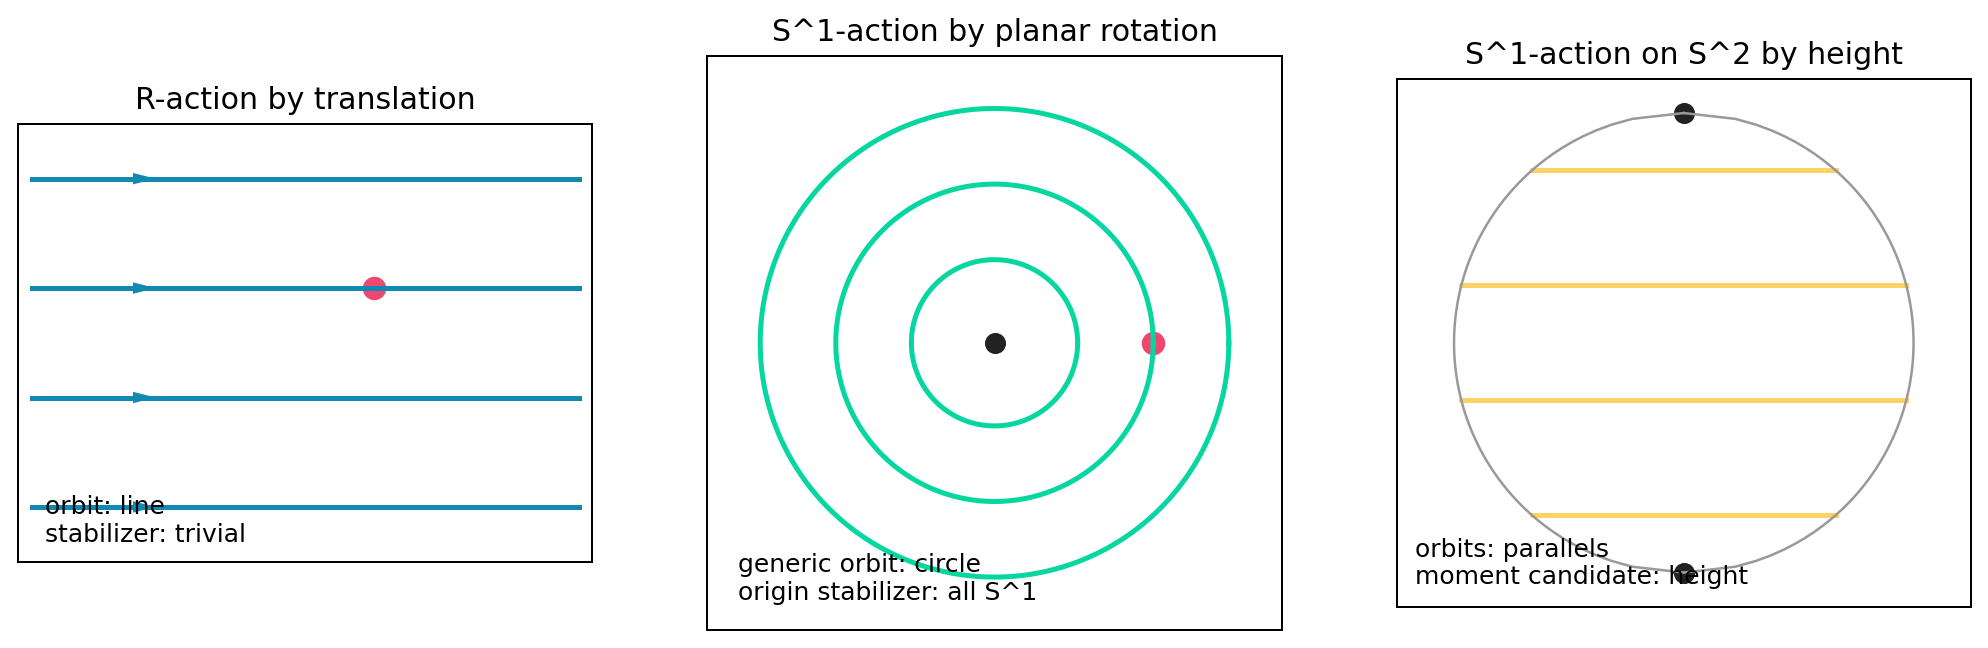

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))

x = np.linspace(-2, 2, 7)
for y in [-1.2, -0.4, 0.4, 1.2]:
    axes[0].plot(x, np.full_like(x, y), color="#118ab2", lw=2)
    axes[0].arrow(-1.8, y, 0.55, 0, head_width=0.06, head_length=0.12, color="#118ab2")
axes[0].scatter([0.5], [0.4], color="#ef476f", s=70)
axes[0].set_title("R-action by translation")
axes[0].set_aspect("equal")
axes[0].set_xlim(-2.1, 2.1)
axes[0].set_ylim(-1.6, 1.6)
axes[0].text(-1.9, -1.45, "orbit: line\nstabilizer: trivial", fontsize=10)

angles = np.linspace(0, 2 * np.pi, 260)
for radius in [0.55, 1.05, 1.55]:
    axes[1].plot(radius * np.cos(angles), radius * np.sin(angles), color="#06d6a0", lw=2)
axes[1].scatter([0], [0], color="#222222", s=55)
axes[1].scatter([1.05], [0], color="#ef476f", s=70)
axes[1].set_title("S^1-action by planar rotation")
axes[1].set_aspect("equal")
axes[1].set_xlim(-1.9, 1.9)
axes[1].set_ylim(-1.9, 1.9)
axes[1].text(-1.7, -1.7, "generic orbit: circle\norigin stabilizer: all S^1", fontsize=10)

h = np.linspace(-1, 1, 80)
for level in [-0.75, -0.25, 0.25, 0.75]:
    radius = math.sqrt(1 - level**2)
    axes[2].plot(radius * np.cos(angles), np.full_like(angles, level), color="#ffd166", lw=2)
axes[2].plot(np.sqrt(1 - h**2), h, color="#999999", lw=1)
axes[2].plot(-np.sqrt(1 - h**2), h, color="#999999", lw=1)
axes[2].scatter([0, 0], [-1, 1], color="#222222", s=55, label="fixed poles")
axes[2].set_title("S^1-action on S^2 by height")
axes[2].set_aspect("equal")
axes[2].set_xlim(-1.25, 1.25)
axes[2].set_ylim(-1.15, 1.15)
axes[2].text(-1.17, -1.05, "orbits: parallels\nmoment candidate: height", fontsize=10)

for ax in axes:
    ax.grid(True, alpha=0.2)
    ax.set_xticks([])
    ax.set_yticks([])

orbit_stabilizer_ledger = {
    "translation_R_on_plane": {"sample_orbit_dimension": 1, "generic_stabilizer_dimension": 0},
    "rotation_S1_on_punctured_plane": {"sample_orbit_dimension": 1, "generic_stabilizer_dimension": 0, "origin_stabilizer_dimension": 1},
    "rotation_S1_on_sphere": {"generic_orbit_dimension": 1, "pole_orbit_dimension": 0, "pole_stabilizer_dimension": 1},
}
orbit_path = FIGURES / "orbit-stabilizer-action-models.png"
fig.savefig(orbit_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert orbit_stabilizer_ledger["translation_R_on_plane"]["generic_stabilizer_dimension"] == 0
assert orbit_stabilizer_ledger["rotation_S1_on_sphere"]["pole_stabilizer_dimension"] == 1
display_artifact(rel(orbit_path))

## Symplectic And Hamiltonian Actions

A symplectic action preserves `omega`; a Hamiltonian one-parameter action supplies a function whose differential is the contraction of `omega` with the generated vector field. The lecture gives two basic models: translation in a `y_1` direction on standard `R^{2n}`, generated by the Hamiltonian `H=x_1`, and circle rotation on the sphere, generated by height in cylindrical coordinates. The planar rotation check below uses the same convention as the later moment-map preview: for `omega = dx wedge dy`, the generator `X=(-y, x)` satisfies `i_X omega = d(-r^2/2)`.

Notice the distinction the course is building toward. Preserving the form is a property of the action; having a Hamiltonian is an extra exactness statement about the infinitesimal generator. The next lecture upgrades the list of Hamiltonian functions for every Lie algebra direction into one moment map.

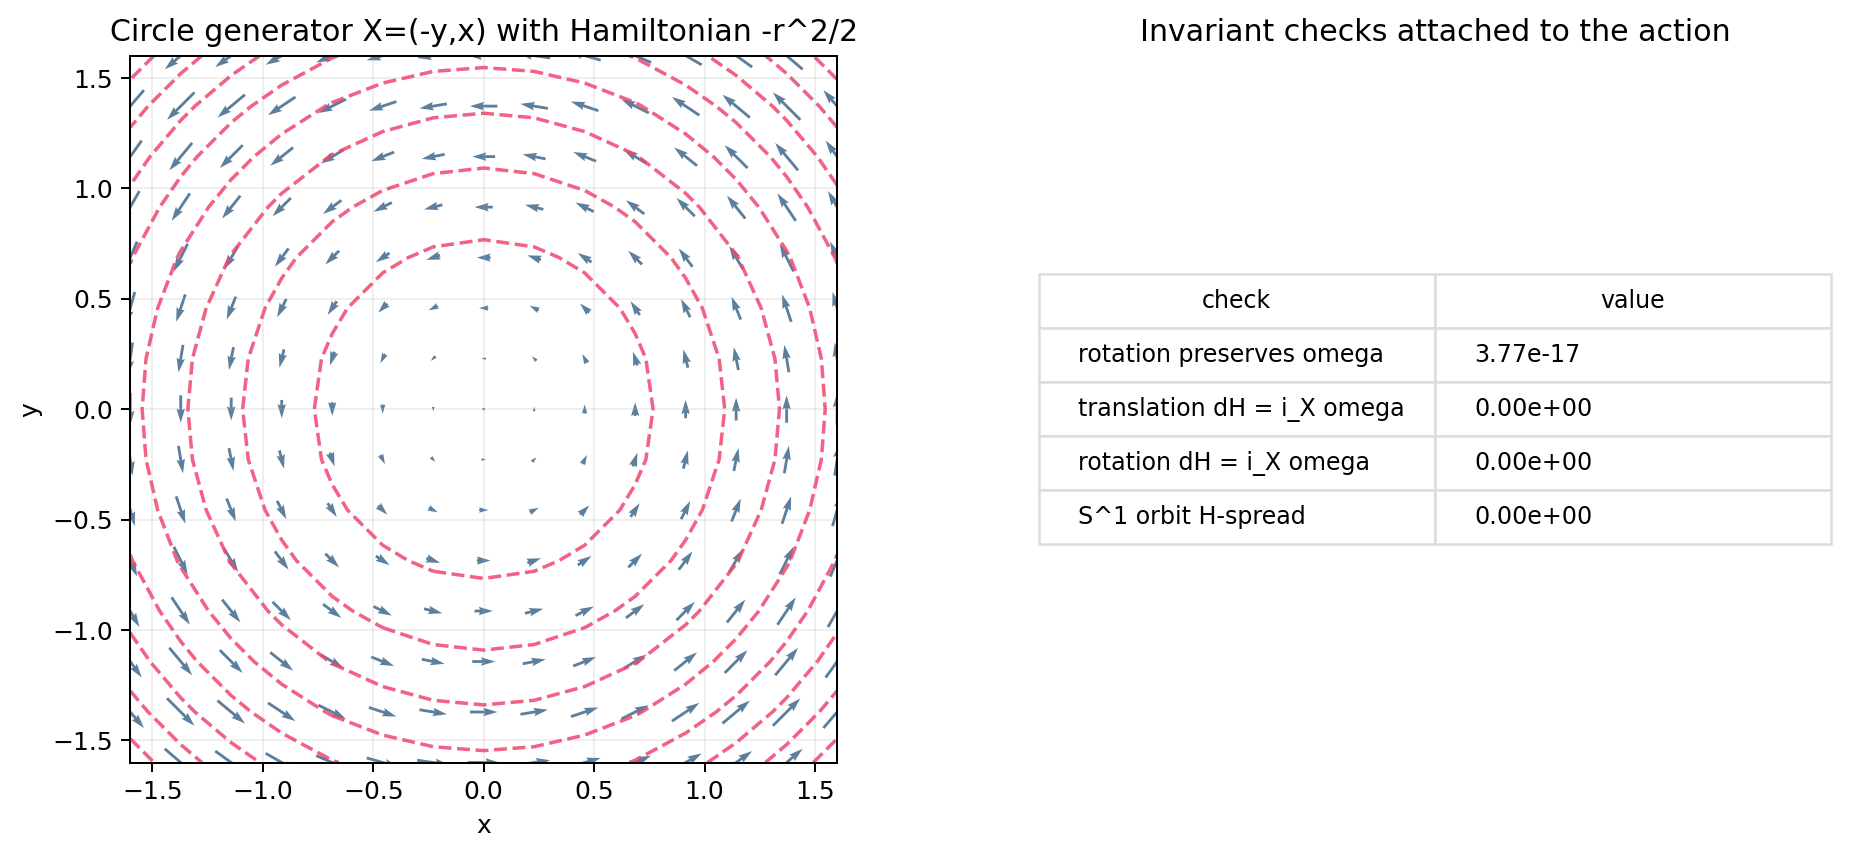

In [5]:
J = np.array([[0.0, 1.0], [-1.0, 0.0]])
A = rotation(0.73)
symplectic_residual = float(np.linalg.norm(A.T @ J @ A - J))

translation_X = np.array([0.0, -1.0])
translation_iXomega = np.array([-translation_X[1], translation_X[0]])
translation_dH = np.array([1.0, 0.0])
translation_hamiltonian_residual = float(np.linalg.norm(translation_iXomega - translation_dH))

sample = np.array([0.8, -0.45])
rotation_X = np.array([-sample[1], sample[0]])
rotation_iXomega = np.array([-rotation_X[1], rotation_X[0]])
rotation_dH = -sample
rotation_hamiltonian_residual = float(np.linalg.norm(rotation_iXomega - rotation_dH))

grid_x, grid_y = np.meshgrid(np.linspace(-1.6, 1.6, 15), np.linspace(-1.6, 1.6, 15))
U = -grid_y
V = grid_x
H = -0.5 * (grid_x**2 + grid_y**2)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.1))
axes[0].quiver(grid_x, grid_y, U, V, color="#26547c", alpha=0.75, pivot="mid")
axes[0].contour(grid_x, grid_y, H, levels=8, colors="#ef476f", linewidths=1.4, alpha=0.85)
axes[0].set_title("Circle generator X=(-y,x) with Hamiltonian -r^2/2")
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.2)
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

columns = ["check", "value"]
rows = [
    ["rotation preserves omega", f"{symplectic_residual:.2e}"],
    ["translation dH = i_X omega", f"{translation_hamiltonian_residual:.2e}"],
    ["rotation dH = i_X omega", f"{rotation_hamiltonian_residual:.2e}"],
    ["S^1 orbit H-spread", f"{np.ptp([-0.5 for _ in range(8)]):.2e}"],
]
axes[1].axis("off")
table = axes[1].table(cellText=rows, colLabels=columns, loc="center", cellLoc="left")
table.scale(1, 1.8)
for cell in table.get_celld().values():
    cell.set_edgecolor("#dddddd")
    cell.set_fontsize(10.5)
axes[1].set_title("Invariant checks attached to the action")

ham_path = FIGURES / "symplectic-hamiltonian-action-checks.png"
fig.savefig(ham_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert symplectic_residual < 1e-12
assert translation_hamiltonian_residual < 1e-12
assert rotation_hamiltonian_residual < 1e-12
display_artifact(rel(ham_path))

## Adjoint And Coadjoint Bookkeeping

The adjoint representation comes from conjugating the group by one of its own elements and differentiating at the identity. For matrix groups this is `Ad_g(Y)=gYg^{-1}`. Differentiating `Ad_exp(tX)Y` at `t=0` gives the Lie bracket `[X,Y]`. The coadjoint action is the dual representation: it acts on covectors so that the natural pairing with `g` remains consistent. The inverse in the definition is exactly what turns this into a left action.

For moment maps, this is not optional notation. If a group action changes the point `p` in the manifold, the moment map value `mu(p)` must change in the dual Lie algebra in the compatible way. This chapter supplies the representation language; Lecture 22 will add the map.

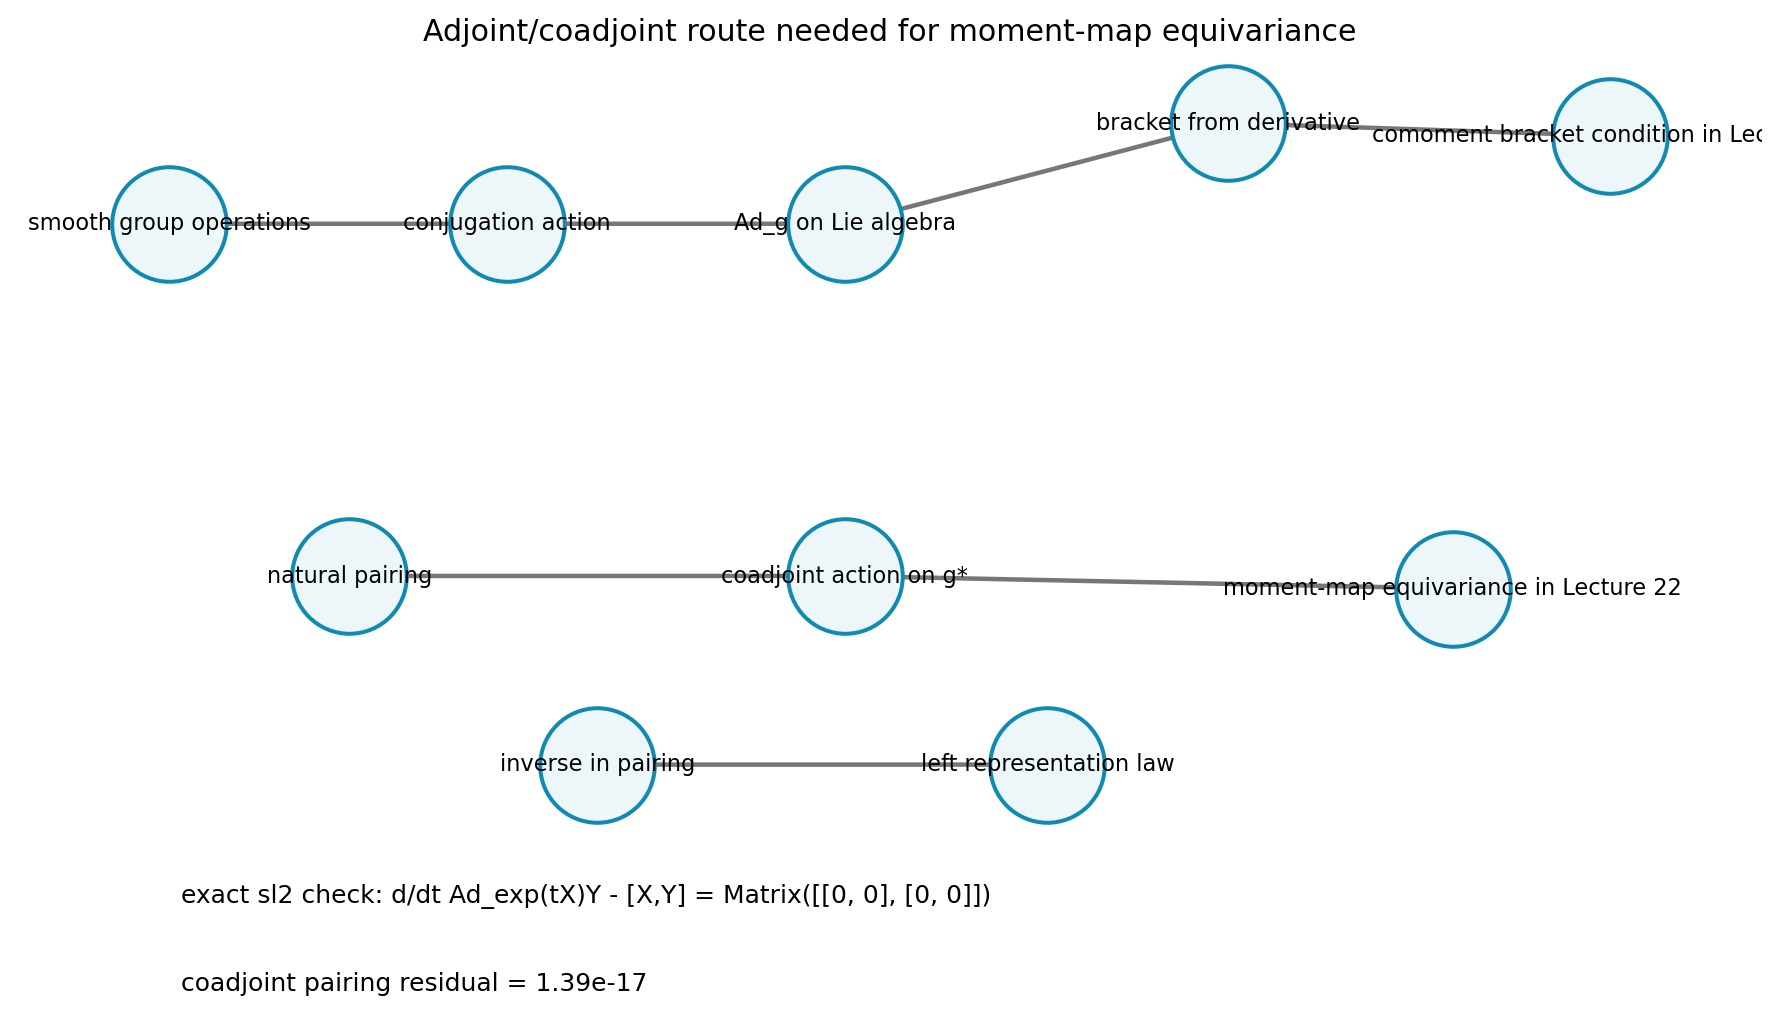

In [6]:
X = sp.Matrix([[0, 1], [0, 0]])
Y = sp.Matrix([[0, 0], [1, 0]])
tau = sp.symbols("tau")
g_tau = sp.exp(tau * X)
ad_curve = g_tau * Y * g_tau.inv()
ad_derivative = sp.diff(ad_curve, tau).subs(tau, 0)
bracket = X * Y - Y * X
adjoint_bracket_residual = sp.simplify(ad_derivative - bracket)

g = np.array([[1.2, 0.35], [0.1, 0.9]])
xi = np.array([[2.0, -0.4], [0.25, 0.6]])
Z = np.array([[0.0, 1.0], [-0.3, 0.2]])
Ad_g_inv_Z = np.linalg.inv(g) @ Z @ g
Ad_star_g_xi = np.linalg.inv(g).T @ xi @ g.T
left_pairing = float(np.trace(Ad_star_g_xi.T @ Z))
right_pairing = float(np.trace(xi.T @ Ad_g_inv_Z))
coadjoint_pairing_residual = abs(left_pairing - right_pairing)

G = nx.DiGraph()
edges = [
    ("smooth group operations", "conjugation action"),
    ("conjugation action", "Ad_g on Lie algebra"),
    ("Ad_g on Lie algebra", "bracket from derivative"),
    ("natural pairing", "coadjoint action on g*"),
    ("inverse in pairing", "left representation law"),
    ("coadjoint action on g*", "moment-map equivariance in Lecture 22"),
    ("bracket from derivative", "comoment bracket condition in Lecture 22"),
]
G.add_edges_from(edges)
pos = {
    "smooth group operations": (0, 2),
    "conjugation action": (1.5, 2),
    "Ad_g on Lie algebra": (3, 2),
    "bracket from derivative": (4.7, 2.4),
    "natural pairing": (0.8, 0.6),
    "coadjoint action on g*": (3, 0.6),
    "inverse in pairing": (1.9, -0.15),
    "left representation law": (3.9, -0.15),
    "moment-map equivariance in Lecture 22": (5.7, 0.55),
    "comoment bracket condition in Lecture 22": (6.4, 2.35),
}

fig, ax = plt.subplots(figsize=(12.5, 5.6))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=18, edge_color="#777777", width=1.8)
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2100, node_color="#edf6f9", edgecolors="#118ab2", linewidths=1.6)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9)
ax.text(0.05, -0.7, f"exact sl2 check: d/dt Ad_exp(tX)Y - [X,Y] = {adjoint_bracket_residual}", fontsize=10)
ax.text(0.05, -1.05, f"coadjoint pairing residual = {coadjoint_pairing_residual:.2e}", fontsize=10)
ax.set_axis_off()
ax.set_title("Adjoint/coadjoint route needed for moment-map equivariance")
adjoint_path = FIGURES / "adjoint-coadjoint-proof-route.png"
fig.savefig(adjoint_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert adjoint_bracket_residual == sp.zeros(2)
assert coadjoint_pairing_residual < 1e-12
display_artifact(rel(adjoint_path))

## Hermitian-Matrix Orbit Probe

The homework at the end of the lecture asks the reader to analyze the `U(n)` conjugation action on Hermitian matrices. The computational lesson is: conjugation preserves eigenvalues, stabilizers are the unitary matrices that commute with the chosen Hermitian matrix, and the orbit inherits a two-form after quotienting out exactly those kernel directions.

For `2 x 2` traceless Hermitian matrices, the Pauli-matrix coordinates make the orbit visible. A matrix `x sigma_x + y sigma_y + z sigma_z` has eigenvalues `+-sqrt(x^2+y^2+z^2)`. Fixing the spectrum fixes the radius. Thus the generic orbit is a sphere; a scalar matrix is the degenerate one-point orbit. This is the low-dimensional shadow of the flag-manifold description in the homework.

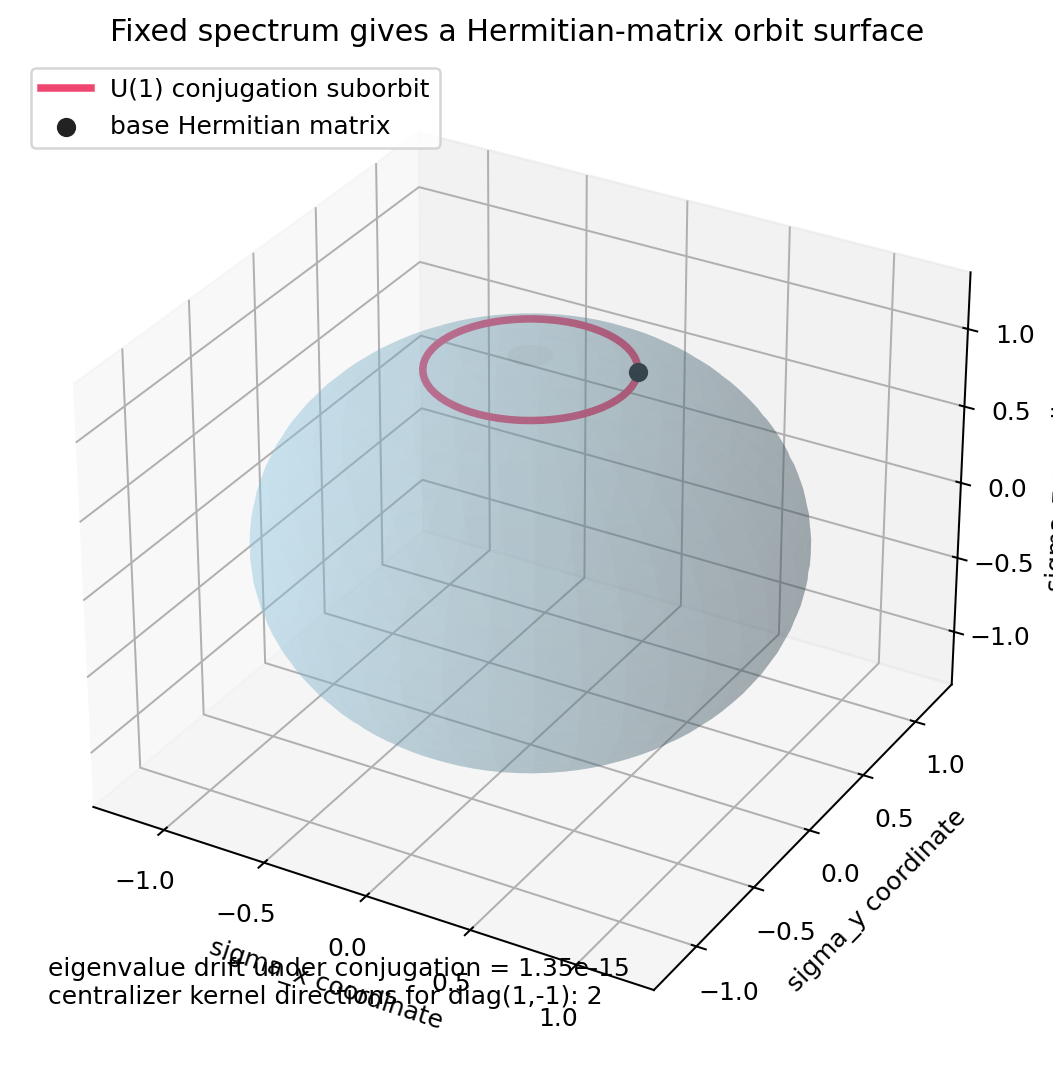

In [7]:
sigma_x = np.array([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.array([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.array([[1, 0], [0, -1]], dtype=complex)
pauli = [sigma_x, sigma_y, sigma_z]

def hermitian_from_vector(v: np.ndarray) -> np.ndarray:
    return v[0] * sigma_x + v[1] * sigma_y + v[2] * sigma_z


def unitary_z(angle: float) -> np.ndarray:
    return np.array([[np.exp(0.5j * angle), 0], [0, np.exp(-0.5j * angle)]])


base_vector = np.array([0.4, 0.2, 1.1])
base_matrix = hermitian_from_vector(base_vector)
base_eigs = np.sort(np.linalg.eigvalsh(base_matrix).real)
conjugated_eigs = []
orbit_points = []
for angle in np.linspace(0, 2 * np.pi, 64):
    Umat = unitary_z(angle)
    moved = Umat @ base_matrix @ Umat.conj().T
    conjugated_eigs.append(np.sort(np.linalg.eigvalsh(moved).real))
    orbit_points.append([
        0.5 * np.trace(moved @ sigma_x).real,
        0.5 * np.trace(moved @ sigma_y).real,
        0.5 * np.trace(moved @ sigma_z).real,
    ])
orbit_points = np.array(orbit_points)
eigenvalue_drift = float(max(np.linalg.norm(eigs - base_eigs) for eigs in conjugated_eigs))

xi = sigma_z
u2_basis = [1j * np.eye(2), 1j * sigma_x, 1j * sigma_y, 1j * sigma_z]
centralizer_norms = [float(np.linalg.norm(B @ xi - xi @ B)) for B in u2_basis]
centralizer_kernel_count = sum(norm < 1e-12 for norm in centralizer_norms)

phi = np.linspace(0, np.pi, 40)
theta3 = np.linspace(0, 2 * np.pi, 80)
PHI, THETA = np.meshgrid(phi, theta3)
radius = np.linalg.norm(base_vector)
SX = radius * np.sin(PHI) * np.cos(THETA)
SY = radius * np.sin(PHI) * np.sin(THETA)
SZ = radius * np.cos(PHI)

fig = plt.figure(figsize=(10.5, 7.2))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(SX, SY, SZ, color="#8ecae6", alpha=0.25, linewidth=0)
ax.plot(orbit_points[:, 0], orbit_points[:, 1], orbit_points[:, 2], color="#ef476f", lw=3, label="U(1) conjugation suborbit")
ax.scatter([base_vector[0]], [base_vector[1]], [base_vector[2]], color="#222222", s=45, label="base Hermitian matrix")
ax.set_title("Fixed spectrum gives a Hermitian-matrix orbit surface")
ax.set_xlabel("sigma_x coordinate")
ax.set_ylabel("sigma_y coordinate")
ax.set_zlabel("sigma_z coordinate")
ax.legend(loc="upper left")
ax.text2D(0.03, 0.05, f"eigenvalue drift under conjugation = {eigenvalue_drift:.2e}\ncentralizer kernel directions for diag(1,-1): {centralizer_kernel_count}", transform=ax.transAxes)
hermitian_path = FIGURES / "hermitian-unitary-orbit-spectrum.png"
fig.savefig(hermitian_path, dpi=180, bbox_inches="tight")
plt.close(fig)

assert eigenvalue_drift < 1e-12
assert centralizer_kernel_count == 2
display_artifact(rel(hermitian_path))

## Consolidated Checks

The final ledger records the invariants that matter for this lecture. The checks intentionally match the chapter's progression: flow law, orbit/stabilizer interpretation, symplectic preservation, Hamiltonian generation, adjoint bracket identity, coadjoint pairing convention, and Hermitian orbit spectrum. When these pass, the notebook has not merely drawn pictures; it has verified the mathematical promises that the pictures are meant to expose.

In [8]:
results = {
    "flow_group_law_residual": flow_residual,
    "symplectic_matrix_residual": symplectic_residual,
    "translation_hamiltonian_residual": translation_hamiltonian_residual,
    "rotation_hamiltonian_residual": rotation_hamiltonian_residual,
    "adjoint_bracket_residual_is_zero": bool(adjoint_bracket_residual == sp.zeros(2)),
    "coadjoint_pairing_residual": coadjoint_pairing_residual,
    "hermitian_eigenvalue_drift": eigenvalue_drift,
    "hermitian_centralizer_kernel_count": centralizer_kernel_count,
}
write_json(CHECKS / "actions-residuals.json", results)

final_sanity = {
    "passed": True,
    "artifacts": [
        rel(FIGURES / "flow-law-one-parameter-action.png"),
        rel(FIGURES / "orbit-stabilizer-action-models.png"),
        rel(FIGURES / "symplectic-hamiltonian-action-checks.png"),
        rel(FIGURES / "adjoint-coadjoint-proof-route.png"),
        rel(FIGURES / "hermitian-unitary-orbit-spectrum.png"),
        rel(CHECKS / "source-span.json"),
        rel(CHECKS / "visual-storyboard.json"),
        rel(CHECKS / "actions-residuals.json"),
    ],
    "assertions": results,
    "coverage_note": "Covers Lecture 21 sections 21.1-21.5 plus the Hermitian-matrix orbit homework without copying source prose.",
}
write_json(CHECKS / "final-sanity.json", final_sanity)

for relative_path in final_sanity["artifacts"]:
    artifact_path = BOOK_ROOT / relative_path
    assert artifact_path.exists(), relative_path
    assert artifact_path.stat().st_size > 0, relative_path

assert final_sanity["passed"]
assert results["flow_group_law_residual"] < 1e-12
assert results["symplectic_matrix_residual"] < 1e-12
assert results["translation_hamiltonian_residual"] < 1e-12
assert results["rotation_hamiltonian_residual"] < 1e-12
assert results["adjoint_bracket_residual_is_zero"]
assert results["coadjoint_pairing_residual"] < 1e-12
assert results["hermitian_eigenvalue_drift"] < 1e-12
assert results["hermitian_centralizer_kernel_count"] == 2

print(json.dumps(final_sanity, indent=2))

{
  "passed": true,
  "artifacts": [
    "artifacts/lecture-21/figures/flow-law-one-parameter-action.png",
    "artifacts/lecture-21/figures/orbit-stabilizer-action-models.png",
    "artifacts/lecture-21/figures/symplectic-hamiltonian-action-checks.png",
    "artifacts/lecture-21/figures/adjoint-coadjoint-proof-route.png",
    "artifacts/lecture-21/figures/hermitian-unitary-orbit-spectrum.png",
    "artifacts/lecture-21/checks/source-span.json",
    "artifacts/lecture-21/checks/visual-storyboard.json",
    "artifacts/lecture-21/checks/actions-residuals.json"
  ],
  "assertions": {
    "flow_group_law_residual": 5.551115123125783e-17,
    "symplectic_matrix_residual": 3.7678426971877816e-17,
    "translation_hamiltonian_residual": 0.0,
    "rotation_hamiltonian_residual": 0.0,
    "adjoint_bracket_residual_is_zero": true,
    "coadjoint_pairing_residual": 1.3877787807814457e-17,
    "hermitian_eigenvalue_drift": 1.3506446028928519e-15,
    "hermitian_centralizer_kernel_count": 2
  },
  

## Takeaways And Exploration

A one-parameter group is the global form of a complete vector field. A Lie group action organizes many diffeomorphisms at once, and orbits/stabilizers describe what the action really does to the manifold. A symplectic action preserves the two-form; a Hamiltonian one-parameter action has an exact contraction `i_X omega = dH`. The adjoint and coadjoint representations are the language needed to state equivariance for moment maps. The Hermitian-matrix example shows the same action ideas in a compact symplectic orbit family.

For a small exploration, replace the rotation matrix in the symplectic check with a shear and decide whether it is symplectic. Then change the vector field in the Hamiltonian panel and compute whether the contraction is an exact differential. This is the local test that the next lecture packages into the moment map.